# 04 — Train and evaluate random forests

This notebook loads the verified CB2 modeling preparation handoff, fits one fresh random forest for each frozen split protocol, and predicts training and validation pKi. It checks performance and the existing validation similarity audit before saving and verifying its own models and reports. Protocol-specific test structures remain reserved.

The final sections add a bounded training-only CV search and save its selected models, predictions, and baseline comparison in a separate tuning subfolder.

**Reference:** All source and supporting files are in [provenance](../provenance/README.md). The data provenance [Excel workbook](../provenance/CB2_data_provenance.xlsx) is generated from the current data and refreshed by each notebook's final cell. Saved outputs below describe the previous execution; printed old paths can differ. Rerun notebooks 00–10 in order to refresh the complete pipeline.

**Random forest reference:** [summary.xlsx](../provenance/models/random_forest/summary.xlsx) combines baseline and tuned results. Supporting evidence is in the adjacent `files/baseline/`, `files/tuning/`, and `files/diagnostics/` folders. A successful complete notebook run replaces both variants together.


## 1. Verify the completed preparation handoff

The explicit preparation manifest identifies immutable fingerprints, targets, assignments, and neighbor diagnostics. The next cell checks its completion record, file hashes, and software versions before using any arrays. Model training starts only after this independent handoff passes.

In [1]:
from pathlib import Path
import sys
# Shared storage helpers keep the notebooks on the same completed dataset.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
from provenance_support import (
    latest_acquisition, current_selection, current_curation, current_preparation,
    current_mlp_baseline, save_review_record, load_review_record,
)
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import platform

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PREP_MANIFEST_REL = current_preparation(project_root)
FOREST_NAMES = {"random": "random_random_forest", "scaffold": "scaffold_random_forest"}
SUBSETS = ("train", "validation", "test")
run_started_at_utc = datetime.now(timezone.utc).isoformat()
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "notebooks/03_modeling_preparation.ipynb").is_file()

def sha256_file(path):
    """Read bytes in chunks to verify recorded source and output files."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# The named run must be complete and must have passed every recorded preparation check.
prep_manifest_path = project_root / PREP_MANIFEST_REL
assert prep_manifest_path.is_file(), f"Preparation manifest is missing: {prep_manifest_path}"
with prep_manifest_path.open(encoding="utf-8") as stream:
    prep_manifest = json.load(stream)
assert prep_manifest.get("completed_at_utc") and prep_manifest.get("stage") == "modeling_preparation"
required_checks = (
    "source_hashes", "saved_arrays_and_fingerprint_bits", "saved_splits_and_scaffolds",
    "saved_audit_reports",
)
for check in required_checks:
    assert prep_manifest.get("verification", {}).get(check) is True, check
assert prep_manifest.get("models_fitted") is False
prep_folder_rel = Path(prep_manifest["output_folder"])
assert (project_root / prep_folder_rel).resolve() == prep_manifest_path.parent.resolve()
required_filenames = (
    "fingerprints_and_targets.npz", "split_assignments.csv", "heldout_training_neighbors.csv",
)
artifact_paths = {}
for filename in required_filenames:
    relative_name = (prep_folder_rel / filename).as_posix()
    assert relative_name in prep_manifest["artifact_sha256"], filename
    artifact_path = project_root / relative_name
    assert artifact_path.is_file(), f"Preparation artifact is missing: {relative_name}"
    assert sha256_file(artifact_path) == prep_manifest["artifact_sha256"][relative_name], relative_name
    artifact_paths[filename] = artifact_path
source_manifest_hash = sha256_file(prep_manifest_path)

# Exact package versions avoid changing fingerprint interpretation or estimator behavior silently.
# The operating system is recorded too: tree libraries can resolve near-tied splits
# differently on Windows and Linux, so results are only exactly comparable on one OS.
installed_versions = {
    "python": platform.python_version(), "platform": platform.system(), "rdkit": rdkit.__version__,
    "numpy": np.__version__, "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "joblib": joblib.__version__,
}
version_differences = {
    package: (saved, installed_versions.get(package))
    for package, saved in prep_manifest["software_versions"].items()
    if installed_versions.get(package) != saved
}
assert not version_differences, f"Preparation/current software versions differ: {version_differences}"
print(f"{'Preparation run':<27} | {PREP_MANIFEST_REL.as_posix()}")
print(f"{'Verified input artifacts':<27} | {len(artifact_paths):>7,}")
print(f"{'scikit-learn version':<27} | {sklearn.__version__}")

Preparation run             | provenance/preparation/manifest.json
Verified input artifacts    |       3
scikit-learn version        | 1.9.0


## 2. Align saved rows with both split protocols

The preparation NPZ supplies one row per curated structure and contains only the fixed fingerprint bits as predictors. Assignments are matched by structure key to this saved row order before any fitting or prediction. Each protocol's train, validation, and test subsets must be complete and disjoint.

In [2]:
# NPZ loading disallows pickled objects and preserves the preparation row order.
with np.load(artifact_paths["fingerprints_and_targets.npz"], allow_pickle=False) as saved:
    X = saved["X"]
    y = saved["y"]
    structure_keys = saved["rdkit_smiles"]
feature_width = int(prep_manifest["configuration"]["fingerprint"]["bits"])
assert X.ndim == 2 and X.shape[1] == feature_width
assert X.dtype == np.uint8 and np.isin(X, (0, 1)).all()
assert y.ndim == 1 and len(X) == len(y) == len(structure_keys)
assert np.isfinite(y).all() and structure_keys.dtype.kind == "U"
assert len(set(structure_keys)) == len(structure_keys) == prep_manifest["counts"]["structures"]

# Map saved labels through structure keys rather than relying on CSV row position.
assignments = pd.read_csv(artifact_paths["split_assignments.csv"], dtype=str, keep_default_na=False)
assert list(assignments.columns) == [
    "split_strategy", "rdkit_smiles", "subset", "scaffold", "fingerprint_group_id"
]
assert len(assignments) == len(structure_keys) * len(FOREST_NAMES)
assert not assignments.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert set(assignments["split_strategy"]) == set(FOREST_NAMES)
assert set(assignments["subset"]) == set(SUBSETS)
split_indices = {}
for strategy in FOREST_NAMES:
    rows = assignments.loc[assignments["split_strategy"].eq(strategy)]
    assert set(rows["rdkit_smiles"]) == set(structure_keys)
    subset_by_key = dict(zip(rows["rdkit_smiles"], rows["subset"]))
    labels = np.asarray([subset_by_key[key] for key in structure_keys])
    split_indices[strategy] = {}
    for subset in SUBSETS:
        indices = np.flatnonzero(labels == subset)
        expected = prep_manifest["counts"]["split_subsets"][strategy][subset]["structures"]
        assert len(indices) == expected and len(indices) > 0
        assert set(structure_keys[indices]) == set(rows.loc[rows["subset"].eq(subset), "rdkit_smiles"])
        split_indices[strategy][subset] = indices
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["validation"])
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["test"])
    assert set(split_indices[strategy]["validation"]).isdisjoint(split_indices[strategy]["test"])
    print(f"{strategy:<10} | train {len(split_indices[strategy]['train']):>5,} | "
          f"validation {len(split_indices[strategy]['validation']):>4,} | "
          f"reserved test {len(split_indices[strategy]['test']):>4,}")

random     | train 2,860 | validation  358 | reserved test  358
scaffold   | train 2,778 | validation  461 | reserved test  337


## 3. Fit one forest per protocol

Both forests use the same fixed starting settings and train only on their protocol's training rows. A forest combines many decision trees to learn associations between binary molecular patterns and pKi. The two estimators remain separate because their training structures differ; neither sees validation or test labels during fitting.

In [3]:
# Keep the original fixed starting settings visible; no parameter search is performed.
forest_parameters = {
    "n_estimators": 300,
    "max_features": 1 / 3,
    "min_samples_leaf": 2,
    "max_depth": None,
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": -1,
}
forests = {}
training_rows = []
training_slices = {}
for strategy, model_name in FOREST_NAMES.items():
    train_indices = split_indices[strategy]["train"]
    assert len(X[train_indices]) == len(y[train_indices])
    training_slices[strategy] = train_indices[:5]
    started = perf_counter()
    model = RandomForestRegressor(**forest_parameters)
    model.fit(X[train_indices], y[train_indices])
    fit_seconds = perf_counter() - started
    assert model.n_features_in_ == feature_width
    assert len(model.estimators_) == forest_parameters["n_estimators"]
    assert np.isfinite(model.predict(X[training_slices[strategy]])).all()
    forests[model_name] = model
    training_rows.append({
        "split_strategy": strategy, "model": model_name,
        "training_structures": len(train_indices), "features": feature_width,
        "fit_seconds": fit_seconds, "fitted_trees": len(model.estimators_),
    })
    print(f"{model_name:<26} | {len(train_indices):>5,} training structures | "
          f"{len(model.estimators_):>3,} trees | {fit_seconds:.1f} s")
training_summary = pd.DataFrame(training_rows)
assert set(forests) == set(FOREST_NAMES.values())

random_random_forest       | 2,860 training structures | 300 trees | 1.4 s


scaffold_random_forest     | 2,778 training structures | 300 trees | 1.3 s


## 4. Predict on training and validation structures

Each newly fitted forest predicts its complete training and validation subsets. A residual is predicted minus observed pKi, so a positive value means predicted affinity is too strong. Predictions keep the protocol in every row because their subset assignments differ; test rows are never passed to `predict`.

In [4]:
# A long table keeps the protocol and subset attached to every molecular prediction.
prediction_rows = []
for strategy, model_name in FOREST_NAMES.items():
    forest = forests[model_name]
    for subset in ("train", "validation"):
        indices = split_indices[strategy][subset]
        # Predict the complete chosen subset with the already-fitted estimator.
        predicted = forest.predict(X[indices])
        observed = y[indices]
        assert len(predicted) == len(indices) and np.isfinite(predicted).all()
        for index, observed_pki, predicted_pki in zip(indices, observed, predicted):
            # Positive residual means affinity was overpredicted on the pKi scale.
            residual = float(predicted_pki - observed_pki)
            prediction_rows.append({
                "split_strategy": strategy, "subset": subset,
                "rdkit_smiles": str(structure_keys[index]),
                "observed_pki": float(observed_pki), "predicted_pki": float(predicted_pki),
                "residual": residual, "absolute_error": abs(residual),
                "squared_error": residual ** 2,
            })
prediction_columns = [
    "split_strategy", "subset", "rdkit_smiles", "observed_pki", "predicted_pki",
    "residual", "absolute_error", "squared_error",
]
predictions = pd.DataFrame(prediction_rows, columns=prediction_columns)
assert not predictions.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(predictions["subset"]) == {"train", "validation"}
for strategy in FOREST_NAMES:
    for subset in ("train", "validation"):
        expected = set(structure_keys[split_indices[strategy][subset]])
        observed = set(predictions.loc[
            predictions["split_strategy"].eq(strategy) & predictions["subset"].eq(subset),
            "rdkit_smiles",
        ])
        assert observed == expected, f"Prediction coverage mismatch: {strategy} {subset}"
print(f"Generated {len(predictions):,} training and validation prediction rows; no test predictions.")

Generated 6,457 training and validation prediction rows; no test predictions.


### Inspect a few forest predictions

The next table shows two training and two validation examples per protocol, including observed pKi, predicted pKi, and signed residual. Structure keys are shortened only for display; the saved prediction CSV retains every full key and full numeric precision.


In [5]:
# Preview real prediction rows without printing thousands of structures.
print(f"{'Protocol':<10} | {'Subset':<10} | {'Structure key (shortened)':<43} | {'Observed':>8} | {'Predicted':>9} | {'Residual':>8}")
for strategy in FOREST_NAMES:
    for subset in ("train", "validation"):
        rows = predictions.loc[
            predictions["split_strategy"].eq(strategy) & predictions["subset"].eq(subset)
        ].head(2)
        for row in rows.itertuples(index=False):
            key = row.rdkit_smiles if len(row.rdkit_smiles) <= 43 else row.rdkit_smiles[:42] + "…"
            print(f"{strategy:<10} | {subset:<10} | {key:<43} | "
                  f"{row.observed_pki:>8.3f} | {row.predicted_pki:>9.3f} | {row.residual:>+8.3f}")


Protocol   | Subset     | Structure key (shortened)                   | Observed | Predicted | Residual
random     | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    6.031 |     6.107 |   +0.076
random     | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    5.543 |     6.071 |   +0.527
random     | validation | Brc1ccc2c(c1)c(OCc1ccc3ccccc3c1)nn2CCN1CCC… |    5.745 |     6.050 |   +0.305
random     | validation | C#CCCCn1cc(C(=O)c2ccc3c(c2)CC(C)(C)C3)c2cc… |    7.620 |     7.379 |   -0.241
scaffold   | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    6.031 |     6.104 |   +0.074
scaffold   | train      | C#CCCC1(CCNC(=O)c2nonc2Cn2nc3nc(C(C)(C)C)n… |    5.543 |     6.110 |   +0.567
scaffold   | validation | C#Cc1cccc(S(=O)(=O)F)c1Cn1nc2nc(C(C)(C)C)n… |    6.376 |     7.456 |   +1.080
scaffold   | validation | C/N=C(\NS(=O)(=O)N1CCSCC1)N1CC(c2ccccc2)C(… |    5.453 |     5.710 |   +0.257


## 5. Summarize prediction error

MAE is average absolute pKi error, while RMSE weights large errors more strongly. R² compares squared error with predicting the evaluated subset's mean, can be negative, and is undefined for fewer than two observations or a constant target. Training–validation gaps describe generalization for each forest without identifying their cause.

In [6]:
# Compute each protocol/subset independently; their validation molecules differ.
metric_rows = []
for strategy in FOREST_NAMES:
    for subset in ("train", "validation"):
        rows = predictions.loc[
            predictions["split_strategy"].eq(strategy) & predictions["subset"].eq(subset)
        ]
        observed = rows["observed_pki"].to_numpy()
        predicted = rows["predicted_pki"].to_numpy()
        # R² has no useful denominator for a one-row or constant-target subset.
        r2_defined = len(rows) >= 2 and np.max(observed) > np.min(observed)
        metric_rows.append({
            "split_strategy": strategy, "subset": subset, "n_structures": len(rows),
            "mae_pki": float(mean_absolute_error(observed, predicted)),
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))),
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else "undefined_small_or_constant_target",
        })
metrics = pd.DataFrame(metric_rows)
print(f"{'Protocol':<11} | {'Subset':<10} | {'Structures':>10} | {'MAE':>8} | {'RMSE':>8} | {'R²':>8}")
for row in metrics.itertuples(index=False):
    r2_text = f"{row.r2:.3f}" if row.r2_status == "defined" else "undefined"
    print(f"{row.split_strategy:<11} | {row.subset:<10} | {row.n_structures:>10,} | "
          f"{row.mae_pki:>8.3f} | {row.rmse_pki:>8.3f} | {r2_text:>8}")
# A positive validation-minus-training gap means higher error on held-out rows.
for strategy in FOREST_NAMES:
    train = metrics.loc[metrics["split_strategy"].eq(strategy) & metrics["subset"].eq("train")].iloc[0]
    valid = metrics.loc[metrics["split_strategy"].eq(strategy) & metrics["subset"].eq("validation")].iloc[0]
    print(f"{strategy:<11} validation minus training | MAE {valid['mae_pki'] - train['mae_pki']:+.3f} pKi | "
          f"RMSE {valid['rmse_pki'] - train['rmse_pki']:+.3f} pKi")
print("Validation protocols contain different molecules and target distributions; their errors are descriptive.")

Protocol    | Subset     | Structures |      MAE |     RMSE |       R²
random      | train      |      2,860 |    0.306 |    0.400 |    0.879
random      | validation |        358 |    0.564 |    0.721 |    0.631
scaffold    | train      |      2,778 |    0.303 |    0.396 |    0.882
scaffold    | validation |        461 |    0.693 |    0.875 |    0.417
random      validation minus training | MAE +0.258 pKi | RMSE +0.321 pKi
scaffold    validation minus training | MAE +0.390 pKi | RMSE +0.478 pKi
Validation protocols contain different molecules and target distributions; their errors are descriptive.


## 6. Relate validation error to prepared similarity findings

Validation predictions join to the saved nearest-training audit by protocol, subset, and structure key. The exact-fingerprint and 0.80 Tanimoto partitions are separate descriptions of the same structures. Exact matches also belong to the high-similarity category, and small categories remain descriptive.

In [7]:
# Read saved neighbor fields as text so Boolean strings are interpreted explicitly.
neighbors = pd.read_csv(
    artifact_paths["heldout_training_neighbors.csv"], dtype=str, keep_default_na=False
)
neighbor_columns = [
    "split_strategy", "subset", "rdkit_smiles", "nearest_training_rdkit_smiles",
    "maximum_tanimoto", "exact_training_fingerprint_match", "nearest_tie_count",
]
assert list(neighbors.columns) == neighbor_columns
validation_neighbors = neighbors.loc[neighbors["subset"].eq("validation")].copy()
assert set(validation_neighbors["split_strategy"]) == set(FOREST_NAMES)
assert not validation_neighbors.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(validation_neighbors["exact_training_fingerprint_match"]) <= {"True", "False"}
validation_neighbors["exact_training_fingerprint_match"] = validation_neighbors[
    "exact_training_fingerprint_match"
].map({"True": True, "False": False}).astype(bool)
validation_neighbors["maximum_tanimoto"] = pd.to_numeric(
    validation_neighbors["maximum_tanimoto"], errors="raise"
)
assert np.isfinite(validation_neighbors["maximum_tanimoto"]).all()
assert validation_neighbors["maximum_tanimoto"].between(0, 1).all()
assert (validation_neighbors["exact_training_fingerprint_match"] ==
        validation_neighbors["maximum_tanimoto"].eq(1.0)).all()
assert validation_neighbors["nearest_training_rdkit_smiles"].str.strip().ne("").all()
for strategy in FOREST_NAMES:
    assert set(validation_neighbors.loc[
        validation_neighbors["split_strategy"].eq(strategy), "rdkit_smiles"
    ]) == set(structure_keys[split_indices[strategy]["validation"]])

# The three-key join prevents a structure in one protocol matching the other.
validation_predictions = predictions.loc[predictions["subset"].eq("validation")].merge(
    validation_neighbors[[
        "split_strategy", "subset", "rdkit_smiles", "nearest_training_rdkit_smiles",
        "maximum_tanimoto", "exact_training_fingerprint_match",
    ]],
    on=["split_strategy", "subset", "rdkit_smiles"], how="left", validate="one_to_one",
    indicator=True,
)
assert validation_predictions["_merge"].eq("both").all()
validation_predictions = validation_predictions.drop(columns="_merge")
assert len(validation_predictions) == len(validation_neighbors)
# The held-out similarity audit has no defined training-row neighbor fields.
training_predictions = predictions.loc[predictions["subset"].eq("train")].copy()
training_predictions["nearest_training_rdkit_smiles"] = ""
training_predictions["maximum_tanimoto"] = np.nan
training_predictions["exact_training_fingerprint_match"] = pd.NA
prediction_export = pd.concat([training_predictions, validation_predictions], ignore_index=True)
prediction_export = prediction_export.sort_values(
    ["split_strategy", "subset", "rdkit_smiles"]
).reset_index(drop=True)

cutoff = prep_manifest["configuration"]["diagnostics"]["high_tanimoto_at_least"]
assert cutoff == 0.80, "This evaluation expects the saved 0.80 diagnostic cutoff."
# Build both separate partitions from the same validation rows.
subgroup_rows = []
for strategy in FOREST_NAMES:
    rows = validation_predictions.loc[validation_predictions["split_strategy"].eq(strategy)]
    partitions = [
        ("exact_training_fingerprint", "exact_match", rows["exact_training_fingerprint_match"]),
        ("exact_training_fingerprint", "no_exact_match", ~rows["exact_training_fingerprint_match"]),
        ("nearest_training_tanimoto_0.80", "below_0.80", rows["maximum_tanimoto"].lt(cutoff)),
        ("nearest_training_tanimoto_0.80", "at_least_0.80", rows["maximum_tanimoto"].ge(cutoff)),
    ]
    for grouping, group, mask in partitions:
        selected = rows.loc[mask]
        observed = selected["observed_pki"].to_numpy()
        predicted = selected["predicted_pki"].to_numpy()
        r2_defined = len(selected) >= 2 and np.max(observed) > np.min(observed) if len(selected) else False
        subgroup_rows.append({
            "split_strategy": strategy, "grouping": grouping, "group": group,
            "n_structures": len(selected),
            "mae_pki": float(mean_absolute_error(observed, predicted)) if len(selected) else np.nan,
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))) if len(selected) else np.nan,
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else (
                "undefined_empty" if not len(selected) else "undefined_small_or_constant_target"
            ),
        })
subgroups = pd.DataFrame(subgroup_rows)
print(f"{'Protocol':<10} | {'Grouping':<31} | {'Category':<15} | {'N':>5} | {'MAE':>7} | {'RMSE':>7}")
for row in subgroups.itertuples(index=False):
    mae = f"{row.mae_pki:.3f}" if row.n_structures else "undefined"
    rmse = f"{row.rmse_pki:.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.grouping:<31} | {row.group:<15} | "
          f"{row.n_structures:>5,} | {mae:>7} | {rmse:>7}")
print("Small subgroups are descriptive; exact mismatch does not imply absence of close analogs.")

Protocol   | Grouping                        | Category        |     N |     MAE |    RMSE
random     | exact_training_fingerprint      | exact_match     |    27 |   0.381 |   0.530
random     | exact_training_fingerprint      | no_exact_match  |   331 |   0.579 |   0.735
random     | nearest_training_tanimoto_0.80  | below_0.80      |   179 |   0.600 |   0.775
random     | nearest_training_tanimoto_0.80  | at_least_0.80   |   179 |   0.529 |   0.664
scaffold   | exact_training_fingerprint      | exact_match     |    18 |   0.547 |   0.687
scaffold   | exact_training_fingerprint      | no_exact_match  |   443 |   0.699 |   0.881
scaffold   | nearest_training_tanimoto_0.80  | below_0.80      |   375 |   0.718 |   0.902
scaffold   | nearest_training_tanimoto_0.80  | at_least_0.80   |    86 |   0.582 |   0.742
Small subgroups are descriptive; exact mismatch does not imply absence of close analogs.


## 7. Plot observed and predicted validation pKi

Each point is one validation structure, with an identity line marking a perfect prediction. Shared axis limits make the protocol panels easier to compare. The two validation sets contain different molecules and are not paired observations.

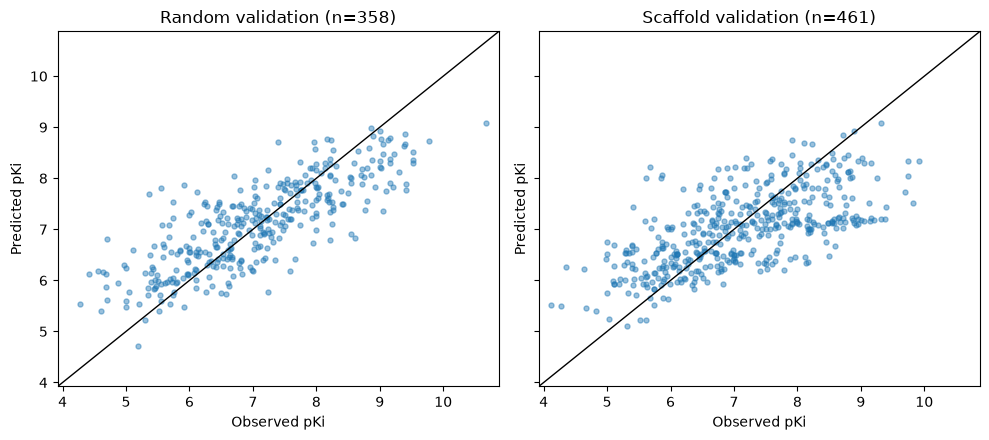

In [8]:
# Use validation points only and share limits between the two protocol panels.
validation_only = prediction_export.loc[prediction_export["subset"].eq("validation")]
lower = float(min(validation_only["observed_pki"].min(), validation_only["predicted_pki"].min()) - 0.2)
upper = float(max(validation_only["observed_pki"].max(), validation_only["predicted_pki"].max()) + 0.2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
# Draw one point per structure and a perfect-prediction reference line.
for axis, strategy in zip(axes, FOREST_NAMES):
    rows = validation_only.loc[validation_only["split_strategy"].eq(strategy)]
    axis.scatter(rows["observed_pki"], rows["predicted_pki"], s=13, alpha=0.45)
    axis.plot([lower, upper], [lower, upper], color="black", linewidth=1)
    axis.set(xlim=(lower, upper), ylim=(lower, upper),
             title=f"{strategy.capitalize()} validation (n={len(rows):,})",
             xlabel="Observed pKi", ylabel="Predicted pKi")
fig.tight_layout()
plt.show()

## 8. Plot error against training similarity

The saved maximum Tanimoto similarity appears on the horizontal axis, and absolute validation error on the vertical axis. The dashed line marks the fixed 0.80 threshold. The plot describes an association and does not establish why any structure is difficult to predict.

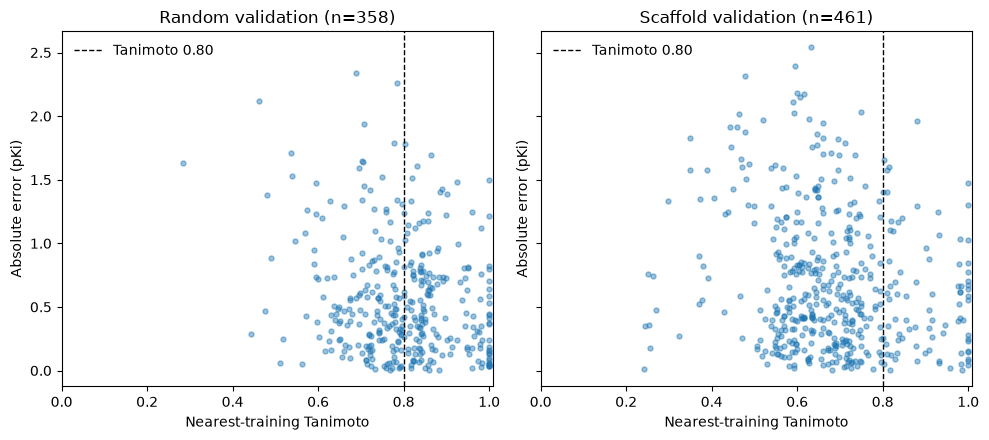

In [9]:
# Use the existing nearest-training values; no similarities are recomputed.
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, FOREST_NAMES):
    rows = validation_only.loc[validation_only["split_strategy"].eq(strategy)]
    axis.scatter(rows["maximum_tanimoto"], rows["absolute_error"], s=13, alpha=0.45)
    # The dashed line marks the cutoff fixed in the modeling manifest.
    axis.axvline(cutoff, color="black", linestyle="--", linewidth=1, label="Tanimoto 0.80")
    axis.set(xlim=(0, 1.01), title=f"{strategy.capitalize()} validation (n={len(rows):,})",
             xlabel="Nearest-training Tanimoto", ylabel="Absolute error (pKi)")
    axis.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

## 9. Save this forest training and evaluation run

One numbered folder holds the two newly fitted forests, their training counts and durations, predictions, metrics, and subgroup summaries. The serialized models are written only after fitting, and the completion manifest waits for disk readback checks. This folder is separate from both the preparation run and the earlier historical forest evaluation.

In [10]:
# Keep the accepted baseline and tuning intact while this complete experiment runs.
# Publish both together only after all audits pass and the combined workbook saves.
from forest_artifacts import new_forest_candidate, publish_forest
from forest_diagnostics import save_cliffs
forest_candidate = new_forest_candidate(project_root)
forest_folder = forest_candidate / "baseline"
models_path = forest_folder / "models.joblib.gz"
training_path = forest_folder / "training_summary.csv"
prediction_path = forest_folder / "predictions.csv"
metrics_path = forest_folder / "metrics.csv"
subgroups_path = forest_folder / "validation_subgroups.csv"
forest_manifest_path = forest_folder / "manifest.json"

joblib.dump(forests, models_path, compress=("gzip", 3))
training_summary.to_csv(training_path, index=False)
prediction_export.to_csv(prediction_path, index=False)
metrics.to_csv(metrics_path, index=False)
subgroups.to_csv(subgroups_path, index=False)
print(f"Saved two forests and four reports to {forest_folder.relative_to(project_root).as_posix()}")
print("The run remains incomplete until its saved files are independently checked.")


Saved two forests and four reports to provenance/models/random_forest/.pending-ovefm8e1/baseline
The run remains incomplete until its saved files are independently checked.


## 10. Verify saved models and reports

The prediction, metric, and subgroup CSVs are reopened and recomputed from their saved values. This cell also reloads the two newly fitted forests, compares their training-slice predictions, checks training metadata, and rehashes the consumed preparation files. It writes a completion manifest only when every check succeeds.

In [11]:
# Read all output columns as text before controlled numeric conversion.
saved_predictions = pd.read_csv(prediction_path, dtype=str, keep_default_na=False)
saved_metrics = pd.read_csv(metrics_path, dtype=str, keep_default_na=False)
saved_subgroups = pd.read_csv(subgroups_path, dtype=str, keep_default_na=False)
assert list(saved_predictions.columns) == list(prediction_export.columns)
assert list(saved_metrics.columns) == list(metrics.columns)
assert list(saved_subgroups.columns) == list(subgroups.columns)
key_columns = ["split_strategy", "subset", "rdkit_smiles"]
assert not saved_predictions.duplicated(key_columns).any()
assert set(saved_predictions["split_strategy"]) == set(FOREST_NAMES)
assert set(saved_predictions["subset"]) == {"train", "validation"}
assert len(saved_predictions) == len(prediction_export)
target_by_key = dict(zip(structure_keys, y))
for strategy in FOREST_NAMES:
    for subset in ("train", "validation"):
        rows = saved_predictions.loc[
            saved_predictions["split_strategy"].eq(strategy) & saved_predictions["subset"].eq(subset)
        ]
        assert set(rows["rdkit_smiles"]) == set(structure_keys[split_indices[strategy][subset]])
        assert set(rows["rdkit_smiles"]).isdisjoint(structure_keys[split_indices[strategy]["test"]])
numeric_fields = ("observed_pki", "predicted_pki", "residual", "absolute_error", "squared_error")
for field in numeric_fields:
    saved_predictions[field] = pd.to_numeric(saved_predictions[field], errors="raise")
    assert np.isfinite(saved_predictions[field]).all(), f"Nonfinite saved prediction field: {field}"
# Reconnect observed targets to the verified NPZ keys instead of trusting CSV alone.
expected_observed = saved_predictions["rdkit_smiles"].map(target_by_key).to_numpy()
np.testing.assert_allclose(saved_predictions["observed_pki"], expected_observed, rtol=0, atol=1e-12)
rebuilt_residual = saved_predictions["predicted_pki"] - saved_predictions["observed_pki"]
np.testing.assert_allclose(saved_predictions["residual"], rebuilt_residual, rtol=0, atol=1e-12)
np.testing.assert_allclose(saved_predictions["absolute_error"], np.abs(rebuilt_residual), rtol=0, atol=1e-12)
np.testing.assert_allclose(saved_predictions["squared_error"], rebuilt_residual ** 2, rtol=0, atol=1e-12)
assert set(saved_predictions["exact_training_fingerprint_match"]) <= {"", "True", "False"}
saved_validation = saved_predictions.loc[saved_predictions["subset"].eq("validation")].copy()
saved_training = saved_predictions.loc[saved_predictions["subset"].eq("train")].copy()
assert saved_training["nearest_training_rdkit_smiles"].eq("").all()
assert saved_training["maximum_tanimoto"].eq("").all()
assert saved_training["exact_training_fingerprint_match"].eq("").all()
assert saved_validation["exact_training_fingerprint_match"].isin(["True", "False"]).all()
saved_validation["maximum_tanimoto"] = pd.to_numeric(saved_validation["maximum_tanimoto"], errors="raise")
assert saved_validation["maximum_tanimoto"].between(0, 1).all()
assert set(zip(saved_validation["split_strategy"], saved_validation["subset"], saved_validation["rdkit_smiles"])) == set(
    zip(validation_neighbors["split_strategy"], validation_neighbors["subset"], validation_neighbors["rdkit_smiles"])
)
audited_neighbor = validation_neighbors.set_index(key_columns)
for row in saved_validation.to_dict("records"):
    audit_row = audited_neighbor.loc[(row["split_strategy"], row["subset"], row["rdkit_smiles"])]
    assert row["nearest_training_rdkit_smiles"] == audit_row["nearest_training_rdkit_smiles"]
    assert np.isclose(row["maximum_tanimoto"], audit_row["maximum_tanimoto"], rtol=0, atol=1e-12)
    assert (row["exact_training_fingerprint_match"] == "True") == audit_row["exact_training_fingerprint_match"]

# Recompute each metric from the CSV rather than comparing only the number of rows.
assert len(saved_metrics) == 4
assert not saved_metrics.duplicated(["split_strategy", "subset"]).any()
for row in saved_metrics.to_dict("records"):
    strategy, subset = row["split_strategy"], row["subset"]
    selected = saved_predictions.loc[
        saved_predictions["split_strategy"].eq(strategy) & saved_predictions["subset"].eq(subset)
    ]
    assert int(row["n_structures"]) == len(selected)
    errors = selected["predicted_pki"].to_numpy() - selected["observed_pki"].to_numpy()
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    assert np.isclose(float(row["mae_pki"]), mae, rtol=0, atol=1e-12)
    assert np.isclose(float(row["rmse_pki"]), rmse, rtol=0, atol=1e-12)
    observed = selected["observed_pki"].to_numpy()
    if len(selected) >= 2 and np.max(observed) > np.min(observed):
        total = float(np.sum((observed - np.mean(observed)) ** 2))
        expected_r2 = 1 - float(np.sum(errors ** 2)) / total
        assert row["r2_status"] == "defined"
        assert np.isclose(float(row["r2"]), expected_r2, rtol=0, atol=1e-12)
    else:
        assert row["r2_status"] == "undefined_small_or_constant_target" and row["r2"] == ""

# The two subgroup partitions are checked independently, including possible empty categories.
assert len(saved_subgroups) == 8
assert not saved_subgroups.duplicated(["split_strategy", "grouping", "group"]).any()
for strategy in FOREST_NAMES:
    rows = saved_validation.loc[saved_validation["split_strategy"].eq(strategy)]
    exact = rows["exact_training_fingerprint_match"].eq("True")
    partition_masks = {
        ("exact_training_fingerprint", "exact_match"): exact,
        ("exact_training_fingerprint", "no_exact_match"): ~exact,
        ("nearest_training_tanimoto_0.80", "below_0.80"): rows["maximum_tanimoto"].lt(cutoff),
        ("nearest_training_tanimoto_0.80", "at_least_0.80"): rows["maximum_tanimoto"].ge(cutoff),
    }
    for (grouping, group), mask in partition_masks.items():
        result = saved_subgroups.loc[
            saved_subgroups["split_strategy"].eq(strategy)
            & saved_subgroups["grouping"].eq(grouping)
            & saved_subgroups["group"].eq(group)
        ]
        assert len(result) == 1
        result = result.iloc[0]
        selected = rows.loc[mask]
        assert int(result["n_structures"]) == len(selected)
        if len(selected):
            errors = selected["predicted_pki"].to_numpy() - selected["observed_pki"].to_numpy()
            assert np.isclose(float(result["mae_pki"]), np.mean(np.abs(errors)), rtol=0, atol=1e-12)
            assert np.isclose(float(result["rmse_pki"]), np.sqrt(np.mean(errors ** 2)), rtol=0, atol=1e-12)
            observed = selected["observed_pki"].to_numpy()
            if len(selected) >= 2 and np.max(observed) > np.min(observed):
                expected_r2 = 1 - np.sum(errors ** 2) / np.sum((observed - np.mean(observed)) ** 2)
                assert result["r2_status"] == "defined"
                assert np.isclose(float(result["r2"]), expected_r2, rtol=0, atol=1e-12)
            else:
                assert result["r2_status"] == "undefined_small_or_constant_target" and result["r2"] == ""
        else:
            assert result["mae_pki"] == result["rmse_pki"] == result["r2"] == ""
            assert result["r2_status"] == "undefined_empty"

# Reload only this run's model artifact and compare its fitted state with the live models.
loaded_forests = joblib.load(models_path)
saved_training_summary = pd.read_csv(training_path)
assert set(loaded_forests) == set(FOREST_NAMES.values())
assert len(saved_training_summary) == len(FOREST_NAMES)
assert not saved_training_summary.duplicated(["split_strategy", "model"]).any()
for strategy, model_name in FOREST_NAMES.items():
    loaded = loaded_forests[model_name]
    assert isinstance(loaded, RandomForestRegressor)
    assert loaded.get_params() == forests[model_name].get_params()
    assert loaded.n_features_in_ == feature_width
    assert len(loaded.estimators_) == forest_parameters["n_estimators"]
    np.testing.assert_allclose(
        loaded.predict(X[training_slices[strategy]]),
        forests[model_name].predict(X[training_slices[strategy]]), rtol=0, atol=1e-12,
    )
    row = saved_training_summary.loc[saved_training_summary["split_strategy"].eq(strategy)].iloc[0]
    assert row["model"] == model_name
    assert int(row["training_structures"]) == len(split_indices[strategy]["train"])
    assert int(row["features"]) == feature_width
    assert int(row["fitted_trees"]) == forest_parameters["n_estimators"]
    assert np.isfinite(float(row["fit_seconds"]))

assert sha256_file(prep_manifest_path) == source_manifest_hash, "Preparation manifest changed during forest modeling."
for filename, path in artifact_paths.items():
    relative_name = (prep_folder_rel / filename).as_posix()
    assert sha256_file(path) == prep_manifest["artifact_sha256"][relative_name], (
        f"Preparation artifact changed during forest modeling: {filename}"
    )
# Write the completion record only after every independent readback check passes.
forest_manifest = {
    "run_started_at_utc": run_started_at_utc,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "notebook": "notebooks/04_random_forest_evaluation.ipynb",
    "stage": "random_forest_training_and_evaluation",
    "output_folder": forest_folder.relative_to(project_root).as_posix(),
    "source_preparation_manifest": PREP_MANIFEST_REL.as_posix(),
    "source_preparation_manifest_sha256": source_manifest_hash,
    "source_artifact_sha256": {
        (prep_folder_rel / filename).as_posix(): prep_manifest["artifact_sha256"][
            (prep_folder_rel / filename).as_posix()
        ] for filename in required_filenames
    },
    "forest_names": FOREST_NAMES,
    "forest_parameters": {strategy: forests[name].get_params() for strategy, name in FOREST_NAMES.items()},
    "training_summary": training_summary.to_dict("records"),
    "counts": {
        "fitted_forests": len(loaded_forests),
        "predictions": len(saved_predictions),
        "overall_metric_rows": len(saved_metrics),
        "subgroup_rows": len(saved_subgroups),
        "subsets": {strategy: {
            subset: len(split_indices[strategy][subset]) for subset in SUBSETS
        } for strategy in FOREST_NAMES},
    },
    "metric_definitions": {
        "residual": "predicted_pki - observed_pki",
        "mae_pki": "mean absolute residual in pKi units",
        "rmse_pki": "square root of mean squared residual in pKi units",
        "r2": "1 - sum(squared residual) / sum((observed - evaluated-subset mean)^2); undefined if n<2 or target constant",
    },
    "subgroup_definitions": {
        "exact_training_fingerprint": ["exact_match", "no_exact_match"],
        "nearest_training_tanimoto_0.80": ["below_0.80", "at_least_0.80"],
        "similarity_cutoff": cutoff,
        "source": "saved validation rows in heldout_training_neighbors.csv",
    },
    "output_sha256": {
        path.relative_to(project_root).as_posix(): sha256_file(path)
        for path in (models_path, training_path, prediction_path, metrics_path, subgroups_path)
    },
    "verification": {
        "input_hashes": True, "saved_models_and_training_state": True, "prediction_keys_and_arithmetic": True,
        "overall_metrics_recomputed": True, "subgroups_recomputed": True,
        "test_excluded": True,
    },
    "fitting_performed": True,
    "tuning_performed": False,
    "test_predictions_performed": False,
    "test_evaluation_performed": False,
    "software_versions": {**installed_versions, "matplotlib": matplotlib.__version__},
}
assert not forest_manifest_path.exists()
with forest_manifest_path.open("w", encoding="utf-8") as stream:
    json.dump(forest_manifest, stream, indent=2)
print(f"Verified two fitted forests, {len(saved_predictions):,} prediction rows, four metric rows, and eight subgroup rows.")
print(f"Completed random forest run: {forest_folder.relative_to(project_root).as_posix()}")

Verified two fitted forests, 6,457 prediction rows, four metric rows, and eight subgroup rows.
Completed random forest run: provenance/models/random_forest/.pending-ovefm8e1/baseline


## 11. Tune the forest using training-only cross-validation

Each protocol keeps its frozen training, validation, and test sets. Five-fold cross-validation (CV) subdivides **only training rows**: four folds fit each candidate and the remaining fold scores it. The random protocol uses shuffled KFold; the scaffold protocol uses GroupKFold so a scaffold cannot appear on both sides of an internal fold. The same fold recipe is used in both model notebooks.

Choose the candidate with the lowest mean fold MAE, then refit it on all original training rows. Outer validation compares the selected model with the baseline afterward. Its scores do not choose the search winner. The reserved test set remains unused until model choices and the final refit procedure are settled. These are the best settings **within this declared grid**, not a guarantee of a global optimum.

The frozen random protocol can place identical fingerprints across folds; the scaffold protocol keeps scaffolds together but can still have fingerprint collisions across different scaffolds. This search preserves the preparation policy and its documented similarity limitations.

Documentation: [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), [GroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GroupKFold.html).

In [12]:
from sklearn.model_selection import GridSearchCV, KFold, GroupKFold, ParameterGrid

# Freeze the search design before fitting candidates or inspecting their validation scores.
tuning_started_at_utc = datetime.now(timezone.utc).isoformat()
tuning_protocols = ("random", "scaffold")
tuning_n_folds = 5
tuning_cv_splits = {}
tuning_fold_rows = []
for protocol in tuning_protocols:
    train_indices = split_indices[protocol]["train"]
    train_keys = structure_keys[train_indices]
    scaffold_by_key = assignments.loc[
        assignments["split_strategy"].eq(protocol)
    ].set_index("rdkit_smiles")["scaffold"]
    train_groups = scaffold_by_key.loc[train_keys].to_numpy()
    # These indices address only the training array; outer validation/test never enter CV.
    if protocol == "random":
        splitter = KFold(n_splits=tuning_n_folds, shuffle=True, random_state=42)
        folds = list(splitter.split(train_indices))
    else:
        splitter = GroupKFold(n_splits=tuning_n_folds)
        folds = list(splitter.split(train_indices, groups=train_groups))
    heldout_counts = np.zeros(len(train_indices), dtype=int)
    for fold_number, (fit_local, valid_local) in enumerate(folds, start=1):
        assert set(fit_local).isdisjoint(valid_local)
        assert set(fit_local) | set(valid_local) == set(range(len(train_indices)))
        if protocol == "scaffold":
            assert set(train_groups[fit_local]).isdisjoint(train_groups[valid_local])
        heldout_counts[valid_local] += 1
        for local_index in valid_local:
            tuning_fold_rows.append({
                "split_strategy": protocol, "rdkit_smiles": train_keys[local_index],
                "scaffold": train_groups[local_index], "cv_validation_fold": fold_number,
            })
    assert np.all(heldout_counts == 1)
    tuning_cv_splits[protocol] = folds

tuning_folds = pd.DataFrame(tuning_fold_rows)
# Twelve combinations include the original baseline settings.
# Trees stay at 300 so the first search focuses on tree complexity and feature sampling.
tuning_grid = {"max_features": [1 / 3, "sqrt"], "min_samples_leaf": [1, 2, 4], "max_depth": [None, 20]}
tuning_estimator = RandomForestRegressor(**forest_parameters)
tuning_baseline_manifest_hash = sha256_file(forest_manifest_path)
print(f"Candidates per protocol: {len(list(ParameterGrid(tuning_grid)))}; CV folds: {tuning_n_folds}")

Candidates per protocol: 12; CV folds: 5


### Run the declared search

The search fits every candidate on the saved training folds and refits the winner. Fold scores below are internal CV validation scores, not scores on the reserved test set.

In [13]:
# Search candidates sequentially; each forest may parallelize its own trees.
# Negative MAE follows sklearn's larger-is-better convention; reports use positive MAE.
tuning_models = {}
tuning_searches = {}
tuning_result_rows = []
tuning_selection = {}
for protocol in tuning_protocols:
    train_indices = split_indices[protocol]["train"]
    search = GridSearchCV(
        tuning_estimator, tuning_grid, scoring="neg_mean_absolute_error",
        cv=tuning_cv_splits[protocol], refit=True, n_jobs=1,
        error_score="raise", return_train_score=False,
    )
    started = perf_counter()
    search.fit(X[train_indices], y[train_indices])
    elapsed = perf_counter() - started
    # refit=True fits the CV winner on all supplied training rows, with no outer holdout.
    tuning_models[protocol] = search.best_estimator_
    tuning_searches[protocol] = search
    tuning_selection[protocol] = {
        "best_candidate_index": int(search.best_index_),
        "best_parameters": search.best_params_,
        "best_mean_cv_mae_pki": float(-search.best_score_),
        "effective_parameters": search.best_estimator_.get_params(),
        "training_structures": int(len(train_indices)), "search_seconds": elapsed,
        "refit_seconds": float(search.refit_time_),
    }
    for candidate_index, parameters in enumerate(search.cv_results_["params"]):
        result = {
            "split_strategy": protocol, "candidate_index": candidate_index,
            "parameters_json": json.dumps(parameters, sort_keys=True),
            "mean_cv_mae_pki": float(-search.cv_results_["mean_test_score"][candidate_index]),
            "std_cv_mae_pki": float(search.cv_results_["std_test_score"][candidate_index]),
            "rank": int(search.cv_results_["rank_test_score"][candidate_index]),
            "selected": candidate_index == search.best_index_,
        }
        # sklearn calls its internal held-out folds 'test'; these are training-only CV folds.
        for fold in range(tuning_n_folds):
            result[f"fold_{fold + 1}_validation_mae_pki"] = float(
                -search.cv_results_[f"split{fold}_test_score"][candidate_index]
            )
        tuning_result_rows.append(result)
    print(f"{protocol:<10} | best CV MAE {(-search.best_score_):.4f} | {elapsed:.1f} seconds")
    print(f"Selected parameters: {search.best_params_}")
tuning_results = pd.DataFrame(tuning_result_rows)

random     | best CV MAE 0.5609 | 43.9 seconds
Selected parameters: {'max_depth': None, 'max_features': 0.3333333333333333, 'min_samples_leaf': 1}


scaffold   | best CV MAE 0.6593 | 43.2 seconds
Selected parameters: {'max_depth': None, 'max_features': 0.3333333333333333, 'min_samples_leaf': 1}


### Compare baseline and selected-model predictions

Training scores describe fit; outer validation scores describe generalization. Optimization can improve CV without improving outer validation. Retain both results and avoid repeatedly changing the grid in response to this holdout.

In [14]:
# Candidate selection is finished before predicting outer validation structures.
tuning_prediction_rows = []
tuning_metric_rows = []
for protocol in tuning_protocols:
    for subset in ("train", "validation"):
        indices = split_indices[protocol][subset]
        predicted = tuning_models[protocol].predict(X[indices])
        observed = y[indices]
        assert np.isfinite(predicted).all()
        for key, actual, estimate in zip(structure_keys[indices], observed, predicted):
            residual = float(estimate - actual)
            tuning_prediction_rows.append({
                "split_strategy": protocol, "subset": subset, "rdkit_smiles": key,
                "observed_pki": float(actual), "predicted_pki": float(estimate),
                "residual": residual, "absolute_error": abs(residual),
                "squared_error": residual ** 2,
            })
        r2_defined = len(observed) >= 2 and np.max(observed) > np.min(observed)
        tuning_metric_rows.append({
            "split_strategy": protocol, "subset": subset, "n_structures": len(indices),
            "mae_pki": float(mean_absolute_error(observed, predicted)),
            "rmse_pki": float(np.sqrt(mean_squared_error(observed, predicted))),
            "r2": float(r2_score(observed, predicted)) if r2_defined else np.nan,
            "r2_status": "defined" if r2_defined else "undefined_small_or_constant_target",
        })
tuning_predictions = pd.DataFrame(tuning_prediction_rows)
tuning_metrics = pd.DataFrame(tuning_metric_rows)

# Keep every baseline in the comparison, even when search does not improve validation.
tuning_baseline_metrics = metrics.copy()
tuning_baseline_metrics["model_variant"] = "baseline"
tuning_selected_metrics = tuning_metrics.assign(model_variant="cv_selected")
tuning_comparison = pd.concat([tuning_baseline_metrics, tuning_selected_metrics], ignore_index=True)
print(f"{'Protocol':<10} | {'Variant':<16} | {'Val. MAE':>9} | {'Val. RMSE':>9} | {'Val. R²':>9}")
for row in tuning_comparison.loc[tuning_comparison["subset"].eq("validation")].itertuples():
    print(f"{row.split_strategy:<10} | {row.model_variant:<16} | {row.mae_pki:>9.4f} | "
          f"{row.rmse_pki:>9.4f} | {row.r2:>9.4f}")
print("CV selected the parameters. Outer validation is a comparison; reserved test remains unused.")
print(f"\n{'Protocol':<10} | {'Observed':>9} | {'Predicted':>9} | {'Abs. error':>10}")
for row in tuning_predictions.loc[tuning_predictions["subset"].eq("validation")].groupby("split_strategy").head(2).itertuples():
    print(f"{row.split_strategy:<10} | {row.observed_pki:>9.4f} | {row.predicted_pki:>9.4f} | {row.absolute_error:>10.4f}")

Protocol   | Variant          |  Val. MAE | Val. RMSE |   Val. R²
random     | baseline         |    0.5643 |    0.7215 |    0.6313
scaffold   | baseline         |    0.6927 |    0.8746 |    0.4166
random     | cv_selected      |    0.5597 |    0.7243 |    0.6284
scaffold   | cv_selected      |    0.6941 |    0.8812 |    0.4076
CV selected the parameters. Outer validation is a comparison; reserved test remains unused.

Protocol   |  Observed | Predicted | Abs. error
random     |    5.7447 |    6.0867 |     0.3420
random     |    7.6198 |    7.3145 |     0.3053
scaffold   |    6.3757 |    7.8915 |     1.5158
scaffold   |    5.4527 |    5.6315 |     0.1787


### Save the search and its provenance

The baseline run receives a `tuning` subfolder containing seven artifacts: fold assignments, all candidate scores, selected parameters, two refitted models, predictions, metrics, and a baseline comparison. A final eighth file, the completion manifest, is written only after readback checks pass.

In [15]:
# A new child folder links this search to the baseline from the same notebook execution.
tuning_folder = forest_candidate / "tuning"
tuning_folder.mkdir(exist_ok=False)
tuning_tables = {
    "cv_folds.csv": tuning_folds,
    "cv_results.csv": tuning_results,
    "predictions.csv": tuning_predictions,
    "metrics.csv": tuning_metrics,
    "baseline_comparison.csv": tuning_comparison,
}
for filename, table in tuning_tables.items():
    table.to_csv(tuning_folder / filename, index=False)
joblib.dump(tuning_models, tuning_folder / "models.joblib.gz", compress=("gzip", 3))
with (tuning_folder / "best_parameters.json").open("w", encoding="utf-8") as stream:
    json.dump(tuning_selection, stream, indent=2)
print(f"Search artifacts: {tuning_folder.relative_to(project_root).as_posix()}")

Search artifacts: provenance/models/random_forest/.pending-ovefm8e1/tuning


### Verify saved search artifacts

Check fold membership, candidate selection, all saved model predictions, metric arithmetic, and source hashes. Every prediction is checked against its own protocol to exclude that protocol’s reserved test structures.

In [16]:
# Read the files back before marking the search complete.
for filename, original in tuning_tables.items():
    reloaded = pd.read_csv(tuning_folder / filename, keep_default_na=False)
    expected = original.fillna("")
    pd.testing.assert_frame_equal(reloaded, expected, check_dtype=False, rtol=1e-12, atol=1e-12)
checked_folds = pd.read_csv(tuning_folder / "cv_folds.csv", keep_default_na=False)
checked_results = pd.read_csv(tuning_folder / "cv_results.csv")
checked_predictions = pd.read_csv(tuning_folder / "predictions.csv")
checked_metrics = pd.read_csv(tuning_folder / "metrics.csv")
checked_models = joblib.load(tuning_folder / "models.joblib.gz")
with (tuning_folder / "best_parameters.json").open(encoding="utf-8") as stream:
    checked_selection = json.load(stream)
assert checked_selection == tuning_selection
assert set(checked_models) == set(tuning_protocols)
assert not checked_folds.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert not checked_predictions.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(checked_predictions["subset"]) == {"train", "validation"}

for protocol in tuning_protocols:
    train_indices = split_indices[protocol]["train"]
    fold_rows = checked_folds.loc[checked_folds["split_strategy"].eq(protocol)]
    assert set(fold_rows["rdkit_smiles"]) == set(structure_keys[train_indices])
    assert set(fold_rows["cv_validation_fold"]) == set(range(1, tuning_n_folds + 1))
    if protocol == "scaffold":
        assert fold_rows.groupby("scaffold")["cv_validation_fold"].nunique().eq(1).all()
    candidate_rows = checked_results.loc[checked_results["split_strategy"].eq(protocol)]
    assert len(candidate_rows) == len(list(ParameterGrid(tuning_grid)))
    fold_scores = candidate_rows[[f"fold_{fold}_validation_mae_pki" for fold in range(1, tuning_n_folds + 1)]].to_numpy()
    assert np.isfinite(fold_scores).all() and (fold_scores >= 0).all()
    np.testing.assert_allclose(candidate_rows["mean_cv_mae_pki"], fold_scores.mean(axis=1), atol=1e-12)
    np.testing.assert_allclose(candidate_rows["std_cv_mae_pki"], fold_scores.std(axis=1), atol=1e-12)
    selected = candidate_rows.loc[candidate_rows["selected"]]
    assert len(selected) == 1 and selected.iloc[0]["rank"] == 1
    assert selected.iloc[0]["candidate_index"] == checked_selection[protocol]["best_candidate_index"]
    assert np.isclose(selected.iloc[0]["mean_cv_mae_pki"], candidate_rows["mean_cv_mae_pki"].min(), atol=1e-12)
    assert json.loads(selected.iloc[0]["parameters_json"]) == checked_selection[protocol]["best_parameters"]
    assert checked_models[protocol].get_params() == tuning_models[protocol].get_params()
    assert checked_models[protocol].n_features_in_ == feature_width
    for subset in ("train", "validation"):
        indices = split_indices[protocol][subset]
        rows = checked_predictions.loc[
            checked_predictions["split_strategy"].eq(protocol) & checked_predictions["subset"].eq(subset)
        ].set_index("rdkit_smiles")
        assert set(rows.index) == set(structure_keys[indices])
        assert set(rows.index).isdisjoint(structure_keys[split_indices[protocol]["test"]])
        rows = rows.loc[structure_keys[indices]]
        # Full readback predictions verify the serialized winner as well as CSV alignment.
        np.testing.assert_allclose(rows["predicted_pki"], checked_models[protocol].predict(X[indices]), rtol=0, atol=1e-10)
        np.testing.assert_allclose(rows["observed_pki"], y[indices], rtol=0, atol=1e-12)
        errors = rows["predicted_pki"].to_numpy() - y[indices]
        np.testing.assert_allclose(rows["residual"], errors, rtol=0, atol=1e-12)
        np.testing.assert_allclose(rows["absolute_error"], np.abs(errors), rtol=0, atol=1e-12)
        np.testing.assert_allclose(rows["squared_error"], errors ** 2, rtol=0, atol=1e-12)
        metric = checked_metrics.loc[
            checked_metrics["split_strategy"].eq(protocol) & checked_metrics["subset"].eq(subset)
        ].iloc[0]
        assert metric["n_structures"] == len(indices)
        np.testing.assert_allclose(metric["mae_pki"], np.abs(errors).mean(), atol=1e-12)
        np.testing.assert_allclose(metric["rmse_pki"], np.sqrt((errors ** 2).mean()), atol=1e-12)
        if metric["r2_status"] == "defined":
            expected_r2 = 1 - np.sum(errors ** 2) / np.sum((y[indices] - y[indices].mean()) ** 2)
            np.testing.assert_allclose(metric["r2"], expected_r2, atol=1e-12)

# Link the completed search to frozen data and the completed baseline run.
assert sha256_file(prep_manifest_path) == source_manifest_hash
for filename, path in artifact_paths.items():
    assert sha256_file(path) == prep_manifest["artifact_sha256"][(prep_folder_rel / filename).as_posix()]
assert sha256_file(forest_manifest_path) == tuning_baseline_manifest_hash
tuning_output_paths = [tuning_folder / filename for filename in tuning_tables]
tuning_output_paths += [tuning_folder / "models.joblib.gz", tuning_folder / "best_parameters.json"]
tuning_manifest = {
    "stage": 'random_forest_hyperparameter_search', "notebook": 'notebooks/04_random_forest_evaluation.ipynb',
    "run_started_at_utc": tuning_started_at_utc,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "output_folder": tuning_folder.relative_to(project_root).as_posix(),
    "source_preparation_manifest": PREP_MANIFEST_REL.as_posix(),
    "source_preparation_manifest_sha256": source_manifest_hash,
    "source_artifact_sha256": {
        path.relative_to(project_root).as_posix(): sha256_file(path) for path in artifact_paths.values()
    },
    "baseline_manifest": forest_manifest_path.relative_to(project_root).as_posix(),
    "baseline_manifest_sha256": tuning_baseline_manifest_hash,
    "configuration": {
        "search": "GridSearchCV", "parameter_grid": tuning_grid,
        "scoring": "neg_mean_absolute_error", "refit": True, "search_n_jobs": 1,
        "folds": tuning_n_folds,
        "random_cv": {"method": "KFold", "shuffle": True, "random_state": 42},
        "scaffold_cv": {"method": "GroupKFold", "shuffle": False, "group": "saved_scaffold"},
        "selection_rule": "minimum unweighted mean fold MAE; first candidate breaks ties",
        "scope": "bounded first search; best within the declared grid",
    },
    "selection": tuning_selection,
    "counts": {"candidates_per_protocol": len(list(ParameterGrid(tuning_grid))),
               "selected_models": len(tuning_models), "prediction_rows": len(tuning_predictions)},
    "output_sha256": {path.relative_to(project_root).as_posix(): sha256_file(path) for path in tuning_output_paths},
    "verification": {"input_hashes": True, "saved_tables_and_selection": True,
                     "training_only_cv_folds": True, "scaffold_cv_groups_disjoint": True,
                     "serialized_model_predictions": True, "metrics_recomputed": True, "test_excluded": True},
    "fitting_performed": True, "tuning_performed": True,
    "outer_validation_used_for_search": False,
    "test_predictions_performed": False, "test_evaluation_performed": False,
    "software_versions": installed_versions,
}
with (tuning_folder / "manifest.json").open("x", encoding="utf-8") as stream:
    json.dump(tuning_manifest, stream, indent=2)
print("Verified training-only CV, saved models, predictions, metrics, and source hashes.")
print(f"Completed search: {tuning_folder.relative_to(project_root).as_posix()}")
# Freeze report-only validation cliff pairs directly from this preparation.
# This avoids depending on a later MLP notebook or on an old MLP dataset.
save_cliffs(project_root, forest_candidate / "diagnostics", PREP_MANIFEST_REL,
            X, y, structure_keys, split_indices)
# Accept one complete experiment and its baseline+tuning summary. Failed saves
# restore the previously accepted files and workbook.
forest_files = publish_forest(project_root, forest_candidate)
forest_folder = forest_files / "baseline"
tuning_folder = forest_files / "tuning"
print(f"Accepted random forest results: {forest_files.relative_to(project_root)}")


Verified training-only CV, saved models, predictions, metrics, and source hashes.
Completed search: provenance/models/random_forest/.pending-ovefm8e1/tuning


Accepted random forest results: provenance/models/random_forest/files


## Stopping point

This notebook contains the fixed baseline and a completed CV search, with training and validation predictions for both. Use this same sequence for later model families, choosing a suitable declared search space for each. After comparing model families, freeze the final choices and refit policy before performing the reserved test evaluation once. No test predictions have been made here.

## Refresh the project reference
After this stage passes its checks, update the model comparison and project file guide. The data provenance workbook is regenerated from the current data. Existing model results remain labeled with the dataset that produced them.


In [17]:
# Verify saved evidence and refresh the Markdown references and the data provenance workbook.
from build_project_reference import build_reference
build_reference()


{
  "checksum_references": 61,
  "recomputed_metric_rows": 8,
  "active_notebooks": 10,
  "model_comparison_rows": 4,
  "current_pipeline": {
    "acquisition": "provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json",
    "selection": "provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json",
    "curation": "provenance/curation/manifest.json",
    "preparation": "provenance/preparation/manifest.json"
  },
  "reports_written": true,
  "presentation_workbook": "preserved unchanged"
}


{'checksum_references': 61,
 'recomputed_metric_rows': 8,
 'active_notebooks': 10,
 'model_comparison_rows': 4,
 'current_pipeline': {'acquisition': 'provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json',
  'selection': 'provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json',
  'curation': 'provenance/curation/manifest.json',
  'preparation': 'provenance/preparation/manifest.json'},
 'reports_written': True,
 'presentation_workbook': 'preserved unchanged'}